![title](imagens/cabec_08g.jpg)

# <font color='green'>Projeto 6 - Marketing para Instituições Financeiras - Parte 03</font>
## <font color='green'>Tratamento de Valores Ausentes - A</font>

## Carregando os Pacotes e o DataSet

In [1]:
# Importação dos Pacotes necessários para este projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Carrega o dataset da Parte 2
df = pd.read_csv("dados/bank-full_parte2.csv") 

In [3]:
# Shape
df.shape

(45211, 19)

In [4]:
# Amostra
df.head()

,Unnamed: 0,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,marital,education
0,0,58.0,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,-1,0,unknown,no,married,tertiary
1,1,44.0,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,-1,0,unknown,no,single,secondary
2,2,33.0,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,married,secondary
3,3,47.0,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,-1,0,unknown,no,married,unknown
4,4,33.0,unknown,0.0,1,no,no,no,unknown,5,may,198,1,-1,0,unknown,no,single,unknown


In [5]:
# Como removemos o id, ao sarvar o arquivo, o pandas cria uma nova coluna de identificação e ele chama de Unnamed:0 
# Vamos removê-la.
df.drop(["Unnamed: 0"], axis = 1, inplace = True)

In [6]:
# Amostra
df.head()

,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,marital,education
0,58.0,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,-1,0,unknown,no,married,tertiary
1,44.0,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,-1,0,unknown,no,single,secondary
2,33.0,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,married,secondary
3,47.0,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,-1,0,unknown,no,married,unknown
4,33.0,unknown,0.0,1,no,no,no,unknown,5,may,198,1,-1,0,unknown,no,single,unknown


In [7]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45190 non-null  float64
 1   job        45211 non-null  object 
 2   salary     45180 non-null  float64
 3   balance    45211 non-null  int64  
 4   default    45211 non-null  object 
 5   housing    45211 non-null  object 
 6   loan       45211 non-null  object 
 7   contact    45211 non-null  object 
 8   day        45211 non-null  int64  
 9   month      45188 non-null  object 
 10  duration   45211 non-null  int64  
 11  campaign   45211 non-null  int64  
 12  pdays      45211 non-null  int64  
 13  previous   45211 non-null  int64  
 14  poutcome   45211 non-null  object 
 15  target     45204 non-null  object 
 16  marital    45211 non-null  object 
 17  education  45211 non-null  object 
dtypes: float64(2), int64(6), object(10)
memory usage: 6.2+ MB


In [8]:
# Temos valores nulos?
df.isna().any()

age           True
job          False
salary        True
balance      False
default      False
housing      False
loan         False
contact      False
day          False
month         True
duration     False
campaign     False
pdays        False
previous     False
poutcome     False
target        True
marital      False
education    False
dtype: bool

In [9]:
# Temos valores nulos?
df.isna().sum()

age          21
job           0
salary       31
balance       0
default       0
housing       0
loan          0
contact       0
day           0
month        23
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
target        7
marital       0
education     0
dtype: int64

## Tratamento de Valores Ausentes

Vamos observar a coluna idade (age). Percebemos acima que existem valores nulos.

In [10]:
# Valores ausentes da variável age
df.age.isnull().sum()

21

In [11]:
# Calcula o percentual de valores ausentes na variável age
df.age.isnull().mean()*100

0.04644887306186547

Como o percentual é baixo não podemos simplesmente eliminar a coluna. 
Podemos, sim, eliminar os registros com valores ausentes (essa ação ocasionaria a perda de 21 linhas no dataset) 
Uma outra opção é fazermos a imputação desses dados ausentes. 
Para trabalhar essa ausência de dados, vamos fazer a imputação de valores.

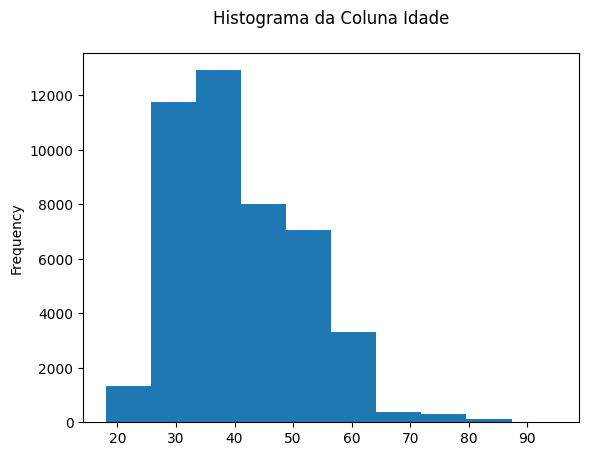

In [12]:
# Histograma
df.age.plot(kind = "hist")
plt.title("Histograma da Coluna Idade\n")
plt.show()

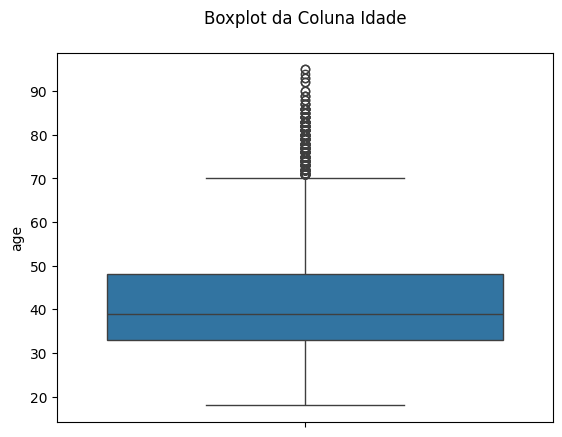

In [13]:
# Boxplot
sns.boxplot(df.age)
plt.title("Boxplot da Coluna Idade\n")
plt.show()

In [14]:
# Vamos verificar qual é a média de idade.
df.age.mean()

40.936578889134765

In [15]:
# Vamos verificar qual é a mediana, valor do meio da distribuição quando os dados estão ordenados.
df.age.median()

39.0

In [16]:
# Vamos verificar qual é a moda, o valor que aparece com mais frequência.
df.age.mode()

0    32.0
Name: age, dtype: float64

Ao verificarmos os gráficos, principalmente o boxplot, e depois as medidas (média, mediana e moda), verificamos que se utilizássemos a média ou a mediana poderiamos alterar o padrão dos dados, em virtude de valores "outliers".
Assim, a medida mais adequada, neste caso em que há poucos valores ausentes, a ser utilizada é a moda! É o que provocará menos impacto no padrão dos dados. 
Vamos então fazer a imputação dessa medida nos valores ausentes da coluna idade (age).

In [17]:
# Vamos preencher com a moda pois são poucos valores ausentes e assim alteramos muito pouco o padrão nos dados.
df.age.fillna("32", inplace = True)

In [18]:
# Agora convertemos para int
df.age = df.age.astype("int")

In [19]:
# Tipo da variável
df.age.dtypes

dtype('int32')

In [20]:
# Média
df.age.mean()

40.932427948950476

In [21]:
# Mediana
df.age.median()

39.0

In [22]:
# Percentual de valores ausentes
df.age.isnull().mean()*100

0.0

## Salvando os Dados desta Etapa 3

In [23]:
# Salvando os dados
df.to_csv('dados/bank-full_parte3.csv')

## Fim da Parte 3